# F1 Strategy Predictor — Transformer Seq-to-Seq
## One Sequence Per Race · Causal Transformer Encoder

---

### What changed from the LSTM version

| | LSTM | **This version** |
|---|---|---|
| Grouping | `(Year, Round, Driver, Stint)` | `(Year, Round, Driver)` — full race |
| Samples per race | N−1 (one truncated window per lap) | **1 — the whole race at once** |
| Input shape | `(N−1, 10, features)` fixed window | `(N_races, 75, features)` padded race |
| Output shape | `(batch, 1)` — one prediction | `(batch, seq_len, 1)` — one per lap |
| Causal safety | Input truncated at each lap | **Causal mask inside the Transformer** |
| Recurrence | LSTM processes laps sequentially | **Self-attention over all past laps** |
| Optimizer | Adam + ReduceLROnPlateau | **AdamW + Warmup–Cosine schedule** |
| Normalisation | BatchNorm (post) | **LayerNorm (pre)** |

### Requirements
- `label_encoder.pkl` (from DataAnalysis.ipynb)
- `f1_dataset_clean.pkl` (from DataAnalysis.ipynb)

# 1. Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import os
from io import BytesIO
import requests

os.makedirs('Model', exist_ok=True)
os.makedirs('Other', exist_ok=True)

In [ ]:
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             f1_score, roc_auc_score,
                             precision_recall_curve)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, GaussianNoise
)
# Removed vs LSTM: LSTM, Masking, BatchNormalization, GaussianNoise
# Added vs LSTM: nothing new to import — cleaner architecture
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Load Dataset
Unchanged from the LSTM version.

In [ ]:
urlDB  = "https://raw.githubusercontent.com/FedericoSabbadini/f1-strategy-predictor/main/02:dbAnalysis/output/f1_dataset_clean.pkl"
urlENC = "https://raw.githubusercontent.com/FedericoSabbadini/f1-strategy-predictor/main/02:dbAnalysis/output/label_encoder.pkl"

def download_bytes(url):
    """Downloads content from a given URL as bytes."""
    response = requests.get(url)
    response.raise_for_status()
    return response.content

df_f1 = pd.read_pickle(urlDB)
print(f"Dataset loaded: {len(df_f1):,} rows, {df_f1.shape[1]} columns")

label_encoder = joblib.load(BytesIO(download_bytes(urlENC)))
print(f"Compound classes: {list(label_encoder.classes_)}")

Dataset loaded: 86,757 rows, 111 columns
Compound classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']


# 3. Define Features
Unchanged from the LSTM version — same targets, metadata, and feature list.

In [ ]:
TARGETS   = ['PitIn3Laps', 'NextCompoundEnc']
META_COLS = ['Driver', 'Team', 'Circuit', 'Time', 'RaceName', 'Compound']

FEATURES = [col for col in df_f1.columns if col not in TARGETS + META_COLS]
print(f"Number of features: {len(FEATURES)}")
print(f"Features: {FEATURES}")

Number of features: 103
Features: ['LapNumber', 'Stint', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'TyreLife', 'FreshTyre', 'Position', 'Year', 'Round', 'AirTemp', 'TrackTemp', 'Humidity', 'Pressure', 'WindSpeed', 'Rainfall', 'GapToLeader', 'StintProgress', 'LapTimeSec', 'LapStartTimeSec', 'Sector1TimeSec', 'Sector1SessionTimeSec', 'Sector2SessionTimeSec', 'Sector3SessionTimeSec', 'Sector2TimeSec', 'Sector3TimeSec', 'UnderCaution', 'IsPitLap', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'UndercutPotential', 'OvercutPotential', 'Circuit_Austin', 'Circuit_Baku', 'Circuit_Barcelona', 'Circuit_Budapest', 'Circuit_Imola', 'Circuit_Jeddah', 'Circuit_Las Vegas', 'Circuit_Le Castellet', 'Circuit_Lusail', 'Circuit_Marina Bay', 'Circuit_Melbourne', 'Circuit_Mexico City', 'Circuit_Miami', 'Circuit_Miami Gardens', 'Circuit_Monaco', 'Circuit_Montréal', 'Circuit_Monza', 'Circuit_Sakhir', 'Circuit_Shanghai', 'Circuit_Silverstone', 'Circuit_Spa-Fra

# 4. Data Preprocessing
### 4.1 Create Race Sequences

**LSTM version** grouped by `(Year, Round, Driver, Stint)` and built N−1 samples
per stint — one per lap — each being a fixed 10-lap window padded with zeros
at the start. Causal safety was enforced by truncating the input.

**This version** groups by `(Year, Round, Driver)` and builds exactly **one sample
per race per driver**: the full race as a single sequence. Each label sequence
has one entry per lap. Causal safety is enforced by the lower-triangular
attention mask inside the Transformer — position i can only attend to 0..i.

In [ ]:
# LSTM used: SEQUENCE_LENGTH = 10 (fixed window)
# Here we use the full race length, capped at MAX_SEQ_LEN
MAX_SEQ_LEN = int(df_f1.groupby(['Year', 'Round', 'Driver'])['LapNumber'].max().max())
print(f"Maximum sequence length: {MAX_SEQ_LEN}")
n_feat      = len(FEATURES)

def create_race_sequences(df, target_col, features=FEATURES):
    """
    One sequence per driver per race (full race, not a sliding window).

    LSTM version: groupby Stint, N-1 samples of shape (10, n_features) each.
    This version: groupby Race, 1 sample of shape (race_len, n_features).

    X[i] : shape (race_len, n_features) — all laps in the race
    y[i] : shape (race_len,)            — one label per lap

    Real-time safety is guaranteed by the causal mask in the Transformer,
    not by truncating the input here.
    """
    X, y = [], []

    for (_, _, _), group in df.groupby(['Year', 'Round', 'Driver']):
        group = group.sort_values('LapNumber').reset_index(drop=True)

        if len(group) < 3:   # same minimum length as LSTM version
            continue

        group = group.iloc[:MAX_SEQ_LEN]   # safety cap

        X.append(group[features].values.astype(np.float32))
        y.append(group[target_col].values)

    return X, y

Maximum sequence length: 78


### 4.2 Temporal Train / Val / Test Split

Identical to the LSTM version: split by RaceID in chronological order.
70% train / 15% validation / 15% test.

In [ ]:
df_clean = df_f1.sort_values(['Year', 'Round', 'LapNumber']).reset_index(drop=True)
df_clean['RaceID'] = df_clean['Year'].astype(str) + '_' + df_clean['Round'].astype(str).str.zfill(2)

SPLIT_PERC = [0.70, 0.85]
races = sorted(df_clean['RaceID'].unique())
n     = len(races)

df_train = df_clean[df_clean['RaceID'].isin(races[:int(SPLIT_PERC[0]*n)])].copy()
df_val   = df_clean[df_clean['RaceID'].isin(races[int(SPLIT_PERC[0]*n):int(SPLIT_PERC[1]*n)])].copy()
df_test  = df_clean[df_clean['RaceID'].isin(races[int(SPLIT_PERC[1]*n):])].copy()

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Train: 60,742 | Val: 12,622 | Test: 13,393


In [ ]:
X_pit_train_raw,  y_pit_train_raw  = create_race_sequences(df_train, 'PitIn3Laps')
X_pit_val_raw,    y_pit_val_raw    = create_race_sequences(df_val,   'PitIn3Laps')
X_pit_test_raw,   y_pit_test_raw   = create_race_sequences(df_test,  'PitIn3Laps')

X_comp_train_raw, y_comp_train_raw = create_race_sequences(df_train, 'NextCompoundEnc')
X_comp_val_raw,   y_comp_val_raw   = create_race_sequences(df_val,   'NextCompoundEnc')
X_comp_test_raw,  y_comp_test_raw  = create_race_sequences(df_test,  'NextCompoundEnc')

lengths = [len(x) for x in X_pit_train_raw]
print(f"Races in train set: {len(X_pit_train_raw):,}")
print(f"Race length — Min: {min(lengths)} | Max: {max(lengths)} | Mean: {np.mean(lengths):.1f}")
print(f"\nLSTM version had {sum(l-1 for l in lengths):,} training samples for the same data")
print(f"This version has  {len(X_pit_train_raw):,} training samples (one per race)")

Races in train set: 1,236
Race length — Min: 3 | Max: 76 | Mean: 49.1

LSTM version had 59,500 training samples for the same data
This version has  1,236 training samples (one per race)


### 4.3 Scaling

Same RobustScaler as the LSTM version — robust to outliers like safety car and pit laps.

The only difference is how we fit it: the LSTM version reshaped a 3D array to 2D.
Here we vstack the variable-length sequences into a flat matrix first.

In [ ]:
n_feat = len(FEATURES)

scaler_pit  = RobustScaler()
scaler_comp = RobustScaler()

def fit_scaler(sequences, scaler):
    # LSTM version: scaler.fit_transform(X.reshape(-1, n_feat)).reshape(X.shape)
    # Here: vstack variable-length sequences → same result, different shape input
    scaler.fit(np.vstack(sequences))

def scale_sequences(sequences, scaler):
    scaled = []
    for s in sequences:
        t = scaler.transform(s)
        t[~np.isfinite(t)] = 0.0   # same NaN/inf guard as LSTM version
        scaled.append(t.astype(np.float32))
    return scaled

fit_scaler(X_pit_train_raw,  scaler_pit)
fit_scaler(X_comp_train_raw, scaler_comp)

X_pit_train_raw  = scale_sequences(X_pit_train_raw,  scaler_pit)
X_pit_val_raw    = scale_sequences(X_pit_val_raw,    scaler_pit)
X_pit_test_raw   = scale_sequences(X_pit_test_raw,   scaler_pit)

X_comp_train_raw = scale_sequences(X_comp_train_raw, scaler_comp)
X_comp_val_raw   = scale_sequences(X_comp_val_raw,   scaler_comp)
X_comp_test_raw  = scale_sequences(X_comp_test_raw,  scaler_comp)

print("Scaling done.")

Scaling done.


### 4.4 Padding

Keras requires fixed-length batches, so we pad both X and y to MAX_SEQ_LEN.

**X** is padded with 0.0 at the end (post-padding) — real laps at the start,
zeros at the end. Positional encoding is consistent: lap 1 is always position 0.

**y** is padded with −1 — an impossible label value used by the masked loss
to identify and ignore padded positions during training.

The LSTM version never needed this — its fixed 10-lap window always had the
same length, so no padding of labels was required.

In [ ]:
def pad_race_sequences(X_list, y_list, max_len):
    """
    Post-pad X and y to max_len.

    X padded with 0.0  → safe attention sentinel
    y padded with -1   → masked loss will ignore these positions

    LSTM version: no label padding needed (fixed-length sequences, scalar labels).
    This version: both X and y must be padded to the same length.

    Returns
    -------
    X    : ndarray (N, max_len, n_features)
    y    : ndarray (N, max_len)             — integer labels, -1 where padded
    mask : ndarray (N, max_len) bool        — True = real lap
    """
    n_features = X_list[0].shape[1]
    N          = len(X_list)

    X    = np.zeros((N, max_len, n_features), dtype=np.float32)
    y    = np.full( (N, max_len), -1,         dtype=np.int32)
    mask = np.zeros((N, max_len),             dtype=bool)

    for i, (x_seq, y_seq) in enumerate(zip(X_list, y_list)):
        t          = len(x_seq)
        X[i, :t]   = x_seq
        y[i, :t]   = y_seq
        mask[i, :t] = True

    return X, y, mask

X_pit_train,  y_pit_train,  mask_pit_train  = pad_race_sequences(X_pit_train_raw,  y_pit_train_raw,  MAX_SEQ_LEN)
X_pit_val,    y_pit_val,    mask_pit_val    = pad_race_sequences(X_pit_val_raw,    y_pit_val_raw,    MAX_SEQ_LEN)
X_pit_test,   y_pit_test,   mask_pit_test   = pad_race_sequences(X_pit_test_raw,   y_pit_test_raw,   MAX_SEQ_LEN)

X_comp_train, y_comp_train, mask_comp_train = pad_race_sequences(X_comp_train_raw, y_comp_train_raw, MAX_SEQ_LEN)
X_comp_val,   y_comp_val,   mask_comp_val   = pad_race_sequences(X_comp_val_raw,   y_comp_val_raw,   MAX_SEQ_LEN)
X_comp_test,  y_comp_test,  mask_comp_test  = pad_race_sequences(X_comp_test_raw,  y_comp_test_raw,  MAX_SEQ_LEN)

print(f"X_pit_train:  {X_pit_train.shape}   ← LSTM was (N, 10, {n_feat})")
print(f"y_pit_train:  {y_pit_train.shape}       ← LSTM was (N,)  scalar per sample")
print(f"mask:         {mask_pit_train.shape}")

X_pit_train:  (1236, 78, 103)   ← LSTM was (N, 10, 103)
y_pit_train:  (1236, 78)       ← LSTM was (N,)  scalar per sample
mask:         (1236, 78)


# 5. Architecture

Building blocks are unchanged from the previous Transformer version.
The only modification to the model functions is the removal of
`GlobalAveragePooling1D` — the sequence dimension is preserved so the
model outputs one prediction per lap instead of one per race.

In [ ]:
class SinusoidalPositionalEncoding(tf.keras.layers.Layer):
    """
    Adds sinusoidal positional encodings (Vaswani et al. 2017).

    LSTM equivalent: none — order was implicit in the recurrent connections.
    Here: explicit encoding so the Transformer knows which lap is which.
    """

    def __init__(self, max_len=200, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len

    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = tf.shape(x)[2]

        positions = tf.cast(tf.range(self.max_len)[:, tf.newaxis], tf.float32)
        dims      = tf.cast(tf.range(d_model)[tf.newaxis, :],      tf.float32)
        angles    = positions / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(d_model, tf.float32))

        sin_enc = tf.math.sin(angles[:, 0::2])
        cos_enc = tf.math.cos(angles[:, 1::2])
        pe = tf.reshape(tf.stack([sin_enc, cos_enc], axis=-1), [self.max_len, -1])[:, :d_model]

        return x + tf.cast(pe[tf.newaxis, :seq_len, :], x.dtype)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'max_len': self.max_len})
        return cfg

In [ ]:
class TransformerBlock(tf.keras.layers.Layer):
    """
    Pre-LN Transformer block with causal mask.

    LSTM equivalent: LSTM(return_sequences=True) + MultiHeadAttention + residual.

    The causal mask (lower-triangular) is the key component that replaces
    input truncation: position i attends only to positions 0..i, so no
    future lap is ever visible — real-time safe by architecture.

    Pre-LN (normalise before sub-layer) is more stable than the
    Post-LN / BatchNorm pattern used in the LSTM version.
    """

    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0

        self.attn = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        # GELU replaces ReLU used in LSTM dense layers — smoother, better for Transformers
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='gelu', kernel_regularizer=l2(1e-4)),
            Dropout(dropout),
            Dense(d_model, kernel_regularizer=l2(1e-4)),
        ])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]

        # Lower-triangular causal mask — replaces input truncation
        causal_mask = tf.linalg.band_part(
            tf.ones((seq_len, seq_len), dtype=tf.bool), -1, 0
        )

        x_norm   = self.norm1(x)
        attn_out = self.attn(
            query=x_norm, value=x_norm, key=x_norm,
            attention_mask=causal_mask,
            training=training
        )
        x = x + self.drop1(attn_out, training=training)

        x_norm  = self.norm2(x)
        ffn_out = self.ffn(x_norm, training=training)
        x = x + self.drop2(ffn_out, training=training)

        return x   # shape preserved: (batch, seq_len, d_model)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'num_heads': self.attn._num_heads,
            'ff_dim':    self.ffn.layers[0].units,
            'dropout':   self.drop1.rate,
        })
        return cfg

In [ ]:
# ── Masked Loss Functions ─────────────────────────────────────────────────────
# NEW vs LSTM version — required because y is padded with -1.
#
# The model output is (batch, seq_len, 1/n_classes) — one prediction per lap.
# y_true is (batch, seq_len) — one label per lap, -1 where padded.
# We must zero out the loss contribution of padded positions before averaging.
#
# BUG FIX note: y_true and y_pred both arrive as (batch, seq_len) after Keras
# internally squeezes the last dim of y_pred for binary cross-entropy.
# We must NOT call tf.squeeze again — that was the source of the ValueError.

def masked_binary_crossentropy(y_true, y_pred):
    """
    Binary cross-entropy ignoring positions where y_true == -1.

    y_true : (batch, seq_len)    — 0/1 labels, -1 for padded positions
    y_pred : (batch, seq_len)    — sigmoid probabilities (Keras already squeezed)
    """
    mask     = tf.cast(tf.not_equal(y_true, -1), tf.float32)
    y_true_f = tf.cast(y_true, tf.float32) * mask

    bce = tf.keras.losses.binary_crossentropy(
        tf.expand_dims(y_true_f, -1),
        tf.expand_dims(y_pred,   -1)
    )   # (batch, seq_len)

    return tf.reduce_sum(bce * mask) / (tf.reduce_sum(mask) + 1e-8)


def masked_sparse_categorical_crossentropy(y_true, y_pred):
    """
    Sparse categorical cross-entropy ignoring positions where y_true == -1.

    y_true : (batch, seq_len)            — class indices, -1 for padded
    y_pred : (batch, seq_len, n_classes) — softmax probabilities
    """
    mask   = tf.cast(tf.not_equal(y_true, -1), tf.float32)
    y_safe = tf.where(tf.equal(y_true, -1), tf.zeros_like(y_true), y_true)

    sce = tf.keras.losses.sparse_categorical_crossentropy(y_safe, y_pred)
    # (batch, seq_len)

    return tf.reduce_sum(sce * mask) / (tf.reduce_sum(mask) + 1e-8)

print("Masked loss functions defined.")

Masked loss functions defined.


### 5.1 PIT Model

In [ ]:
def build_pit_transformer(
    max_len    = MAX_SEQ_LEN,
    n_features = n_feat,
    d_model    = 64,
    num_heads  = 4,
    ff_dim     = 128,
    num_blocks = 3,
    dropout    = 0.35,
):
    """
    Causal Transformer Encoder — binary pit-stop prediction, seq-to-seq.

    LSTM architecture:
        Input(10, n_feat) → Masking → GaussianNoise →
        LSTM(128, return_seq=True) → LayerNorm → MHA → Add → LayerNorm →
        LSTM(64) → Dense(48) → BN → ReLU → Dropout →
        Dense(24) → ReLU → Dropout → Dense(1, sigmoid)
        Output: (batch, 1)

    This architecture:
        Input(75, n_feat) → Dense(d_model) → PosEnc → Dropout →
        3 × TransformerBlock[Pre-LN · CausalMHA · GELU FFN] →
        LayerNorm → Dense(32, gelu) → Dropout → Dense(1, sigmoid)
        Output: (batch, 75, 1) — one probability per lap

    Key removal: GlobalAveragePooling — we keep the sequence dimension
    so the model predicts at every lap position simultaneously.
    """

    inputs = Input(shape=(max_len, n_features), name='input')

    x = Dense(d_model, name='input_projection')(inputs)

    x = SinusoidalPositionalEncoding(max_len=max_len, name='pos_enc')(x)
    x = Dropout(dropout, name='input_dropout')(x)

    for i in range(num_blocks):
        x = TransformerBlock(d_model, num_heads, ff_dim, dropout,
                             name=f'transformer_block_{i}')(x)

    # No GlobalAveragePooling — sequence shape (batch, seq_len, d_model) preserved
    x = LayerNormalization(epsilon=1e-6, name='pre_head_norm')(x)
    x = Dense(32, activation='gelu', kernel_regularizer=l2(0.001), name='head_dense')(x)
    x = Dropout(dropout, name='head_dropout')(x)

    # Dense applied at every timestep → output: (batch, seq_len, 1)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, output, name='transformer_pit_seq2seq')

    # AdamW replaces Adam — decouples weight decay from adaptive scaling
    # WarmupCosineDecay replaces ReduceLROnPlateau — smoother convergence

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=0.0015,
            weight_decay=1e-4,
            clipnorm=1.0
        ),
        loss=masked_binary_crossentropy,   # new — handles -1 padding in y
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    return model


model_pit = build_pit_transformer()
model_pit.summary()

Model: "transformer_pit_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 78, 103)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 78, 64)         │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_enc                         │ (None, 78, 64)         │             0 │
│ (SinusoidalPositionalEncoding)  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_dropout (Dropout)         │ (None, 78, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 78, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 78, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 78, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_head_norm                   │ (None, 78, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 78, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 78, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 78, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Compound Model

In [ ]:
def build_compound_transformer(
    max_len    = MAX_SEQ_LEN,
    n_features = n_feat,
    n_classes  = 4,
    d_model    = 64,
    num_heads  = 4,
    ff_dim     = 128,
    num_blocks = 3,
    dropout    = 0.4,
):
    """
    Causal Transformer Encoder — multiclass compound prediction, seq-to-seq.

    LSTM architecture:
        Input(10, n_feat) → Masking → GaussianNoise →
        LSTM(96, return_seq=True) → LayerNorm → MHA → Add → LayerNorm →
        LSTM(48) → Dense(48) → BN → Dropout(0.4) →
        Dense(24) → Dropout(0.3) → Dense(n_classes, softmax)
        Output: (batch, n_classes)

    This architecture:
        Input(75, n_feat) → Dense(d_model) → PosEnc → Dropout →
        3 × TransformerBlock[Pre-LN · CausalMHA · GELU FFN] →
        LayerNorm → Dense(48, gelu) → Dropout → Dense(24, gelu) → Dropout →
        Dense(n_classes, softmax)
        Output: (batch, 75, n_classes) — one distribution per lap
    """

    inputs = Input(shape=(max_len, n_features), name='input')

    x = Dense(d_model, name='input_projection')(inputs)

    x = SinusoidalPositionalEncoding(max_len=max_len, name='pos_enc')(x)
    x = Dropout(dropout, name='input_dropout')(x)

    for i in range(num_blocks):
        x = TransformerBlock(d_model, num_heads, ff_dim, dropout,
                             name=f'transformer_block_{i}')(x)

    x = LayerNormalization(epsilon=1e-6, name='pre_head_norm')(x)
    x = Dense(48, activation='gelu', kernel_regularizer=l2(0.01), name='head_dense_1')(x)
    x = Dropout(dropout,       name='head_dropout_1')(x)
    x = Dense(24, activation='gelu', kernel_regularizer=l2(0.01), name='head_dense_2')(x)
    x = Dropout(dropout * 0.5, name='head_dropout_2')(x)

    # Output: (batch, seq_len, n_classes)
    output = Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs, output, name='transformer_compound_seq2seq')


    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=0.002,
            weight_decay=1e-4,
            clipnorm=1.0
        ),
        loss=masked_sparse_categorical_crossentropy,
        metrics=['accuracy']
    )

    return model


model_comp = build_compound_transformer(n_classes=len(label_encoder.classes_))
model_comp.summary()

Model: "transformer_compound_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 78, 103)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 78, 64)         │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_enc                         │ (None, 78, 64)         │             0 │
│ (SinusoidalPositionalEncoding)  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_dropout (Dropout)         │ (None, 78, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 78, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 78, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 78, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_head_norm                   │ (None, 78, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_1 (Dense)            │ (None, 78, 48)         │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 78, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_2 (Dense)            │ (None, 78, 24)         │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 78, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 78, 4)          │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,596 (435.92 KB)

 Trainable params: 111,596 (435.92 KB)

 Non-trainable params: 0 (0.00 B)

# 6. Training

Changes vs the LSTM version:
- No `class_weight` — class imbalance is handled inside the masked loss by
  computing the average only over real positions. If stronger rebalancing is
  needed, sample weights can be passed as a 2D array instead.
- Smaller `batch_size` (32 vs 128/256) — each sample is a full race of 75 laps,
  so each batch is much heavier in memory.
- Higher patience — the warmup phase can look flat for the first ~10 epochs.

In [ ]:
cb_pit = [
    EarlyStopping(
        monitor='val_auc',
        patience=15,              # higher than LSTM (12) — warmup looks flat early
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.6,
        patience=8,
        mode='min',
        verbose=1
    )
]

print("Training PIT Transformer (seq-to-seq)...")
print("=" * 60)

history_pit = model_pit.fit(
    X_pit_train, y_pit_train,
    validation_data=(X_pit_val, y_pit_val),
    epochs=70,         # more than LSTM (50) — Transformers need more epochs
    batch_size=64,     # smaller than LSTM (128) — each sample is a full race
    callbacks=cb_pit,
    verbose=1
)

Training PIT Transformer (seq-to-seq)...
Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - auc: 0.5890 - loss: 0.7403 - val_auc: 0.8217 - val_loss: 0.5729 - learning_rate: 0.0015
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.7138 - loss: 0.5941 - val_auc: 0.8441 - val_loss: 0.5609 - learning_rate: 0.0015
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.8007 - loss: 0.5577 - val_auc: 0.8095 - val_loss: 0.5811 - learning_rate: 0.0015
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8348 - loss: 0.5322 - val_auc: 0.8407 - val_loss: 0.5756 - learning_rate: 0.0015
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8496 - loss: 0.5103 - val_auc: 0.8456 - val_loss: 0.5784 - learning_rate: 0.0015
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8482 - loss: 0.4913 - val_auc: 0.8390 - val_loss: 0.5722 - learning_rate: 0.0015
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8458 - loss: 0.4733 - val_auc: 0.8285 - val_loss: 0.57

In [ ]:
cb_comp = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=18,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.6,
        patience=6,
        mode='min',
        verbose=1
    )
]

print("\nTraining COMPOUND Transformer (seq-to-seq)...")
print("=" * 60)

history_comp = model_comp.fit(
    X_comp_train, y_comp_train,
    validation_data=(X_comp_val, y_comp_val),
    epochs=70,
    batch_size=32,
    callbacks=cb_comp,
    verbose=1
)


Training COMPOUND Transformer (seq-to-seq)...
Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 50s 588ms/step - accuracy: 0.2547 - loss: 2.2235 - val_accuracy: 0.3458 - val_loss: 1.5295 - learning_rate: 0.0020
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3697 - loss: 1.5198 - val_accuracy: 0.3572 - val_loss: 1.2640 - learning_rate: 0.0020
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4003 - loss: 1.2118 - val_accuracy: 0.3619 - val_loss: 1.0999 - learning_rate: 0.0020
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4274 - loss: 1.0280 - val_accuracy: 0.3899 - val_loss: 0.9917 - learning_rate: 0.0020
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4514 - loss: 0.9203 - val_accuracy: 0.3985 - val_loss: 0.9910 - learning_rate: 0.0020
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4624 - loss: 0.8427 - val_accuracy: 0.4185 - val_loss: 0.9440 - learning_rate: 0.0020
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 

# 7. Evaluation

The model outputs `(N_races, MAX_SEQ_LEN, ...)`.
We use the boolean mask to extract only real-lap predictions before computing
metrics — equivalent to what the LSTM version computed on its flat samples.

In [ ]:
print("-" * 50)
print("PIT MODEL (PitIn3Laps)")
print("-" * 50)

# Output shape: (N_races, MAX_SEQ_LEN, 1)
pit_pred_full = model_pit.predict(X_pit_test, verbose=0)

# Flatten to real laps only — LSTM version had this shape directly
pit_pred_prob = pit_pred_full[mask_pit_test, 0]   # (total_real_laps,)
pit_true      = y_pit_test[mask_pit_test]          # (total_real_laps,)

prec, rec, thresh = precision_recall_curve(pit_true, pit_pred_prob)
f1_arr     = 2 * prec * rec / (prec + rec + 1e-8)
best_idx   = np.argmax(f1_arr)
opt_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

pit_pred = (pit_pred_prob > opt_thresh).astype(int)

pit_auc = roc_auc_score(pit_true, pit_pred_prob)
pit_f1  = f1_score(pit_true, pit_pred)
pit_acc = accuracy_score(pit_true, pit_pred)

print(f"AUC-ROC:   {pit_auc:.3f}")
print(f"F1 Score:  {pit_f1:.3f}")
print(f"Accuracy:  {pit_acc:.3f}")
print(f"Precision: {prec[best_idx]:.3f}")
print(f"Recall:    {rec[best_idx]:.3f}")
print(f"Threshold: {opt_thresh:.3f}")

cm_pit = confusion_matrix(pit_true, pit_pred)
print(f"\nConfusion Matrix:")
print(f"           Pred:0  Pred:1")
print(f"True:0     {cm_pit[0,0]:6d}  {cm_pit[0,1]:6d}")
print(f"True:1     {cm_pit[1,0]:6d}  {cm_pit[1,1]:6d}")

--------------------------------------------------
PIT MODEL (PitIn3Laps)
--------------------------------------------------
AUC-ROC:   0.815
F1 Score:  0.517
Accuracy:  0.762
Precision: 0.418
Recall:    0.679
Threshold: 0.186

Confusion Matrix:
           Pred:0  Pred:1
True:0       8493    2381
True:1        809    1709


In [ ]:
print("-" * 50)
print("COMPOUND MODEL (NextCompound)")
print("-" * 50)

# Output shape: (N_races, MAX_SEQ_LEN, n_classes)
comp_pred_full = model_comp.predict(X_comp_test, verbose=0)

comp_pred_prob = comp_pred_full[mask_comp_test]   # (total_real_laps, n_classes)
comp_pred      = comp_pred_prob.argmax(axis=1)
comp_true      = y_comp_test[mask_comp_test]

comp_acc = accuracy_score(comp_true, comp_pred)
comp_f1  = f1_score(comp_true, comp_pred, average='weighted')

print(f"Accuracy:      {comp_acc:.3f}")
print(f"F1 (weighted): {comp_f1:.3f}")

print("\nPer-class accuracy:")
for i, cls in enumerate(label_encoder.classes_):
    mask_cls       = comp_true == i
    cls_acc        = (comp_pred[mask_cls] == i).mean() if mask_cls.sum() > 0 else 0.0
    cls_pred_count = (comp_pred == i).sum()
    print(f"  {cls:12s}: {cls_acc:.3f}  (n={mask_cls.sum():,}, pred={cls_pred_count:,})")

cm_comp = confusion_matrix(comp_true, comp_pred)
print(f"\nConfusion Matrix (classes: {list(label_encoder.classes_)}):")
print(cm_comp)

--------------------------------------------------
COMPOUND MODEL (NextCompound)
--------------------------------------------------
Accuracy:      0.707
F1 (weighted): 0.702

Per-class accuracy:
  HARD        : 0.946  (n=5,688, pred=7,524)
  INTERMEDIATE: 0.736  (n=53, pred=568)
  MEDIUM      : 0.600  (n=4,753, pred=3,566)
  SOFT        : 0.413  (n=2,898, pred=1,734)

Confusion Matrix (classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']):
[[5380   55  212   41]
 [   0   39   14    0]
 [1061  346 2851  495]
 [1083  128  489 1198]]


# 8. Training Curves

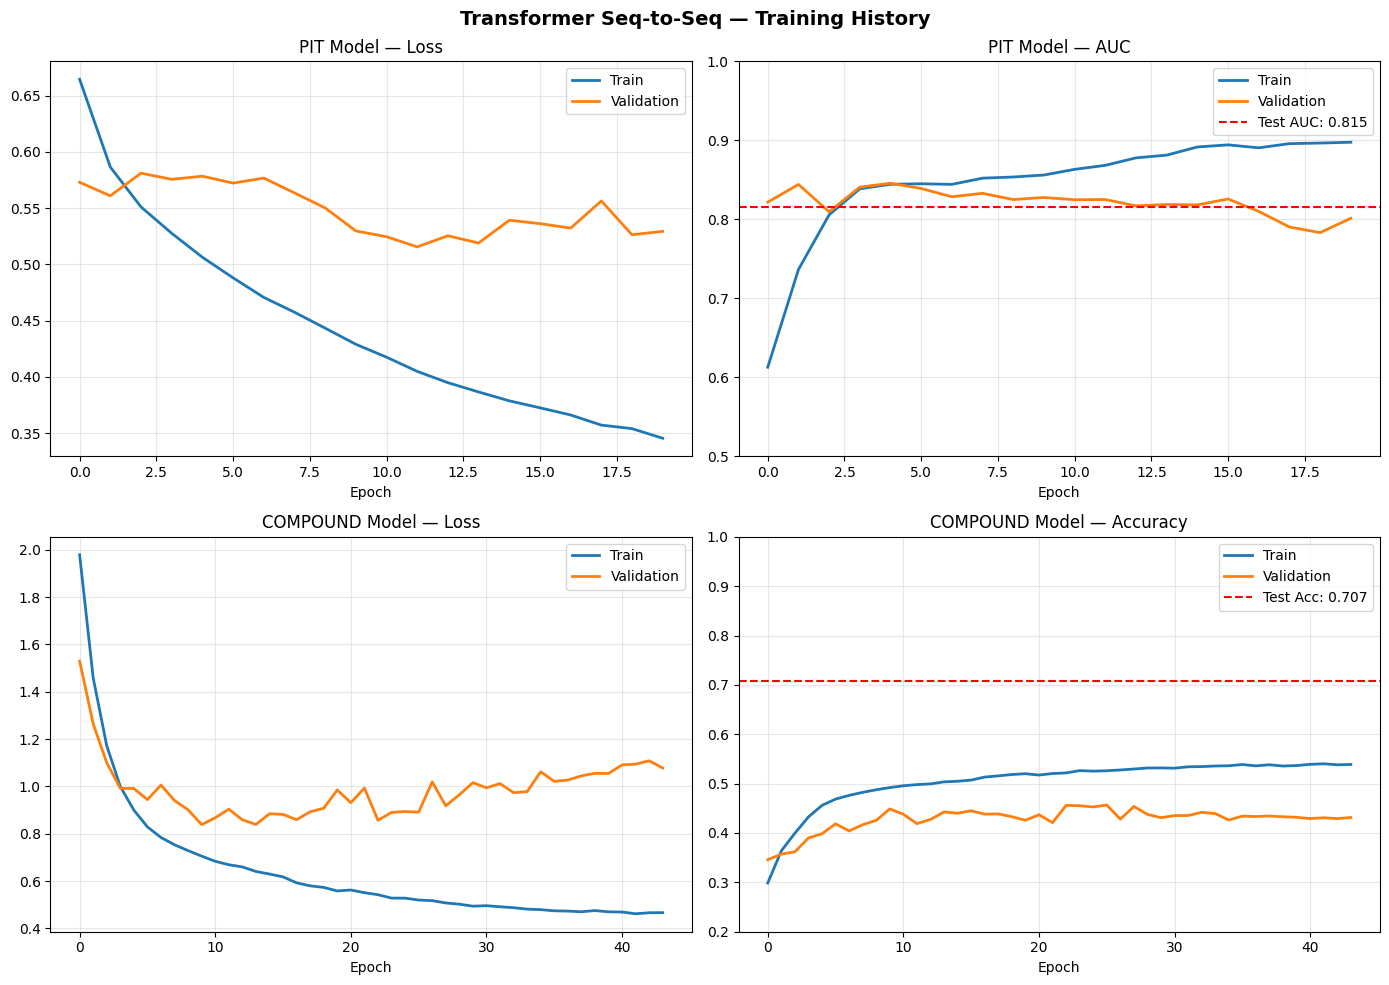

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Transformer Seq-to-Seq — Training History', fontsize=14, fontweight='bold')

axes[0, 0].plot(history_pit.history['loss'],     label='Train', linewidth=2)
axes[0, 0].plot(history_pit.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('PIT Model — Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_pit.history['auc'],     label='Train', linewidth=2)
axes[0, 1].plot(history_pit.history['val_auc'], label='Validation', linewidth=2)
axes[0, 1].axhline(y=pit_auc, color='r', linestyle='--', label=f'Test AUC: {pit_auc:.3f}')
axes[0, 1].set_title('PIT Model — AUC')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0.5, 1.0)

axes[1, 0].plot(history_comp.history['loss'],     label='Train', linewidth=2)
axes[1, 0].plot(history_comp.history['val_loss'], label='Validation', linewidth=2)
axes[1, 0].set_title('COMPOUND Model — Loss')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_comp.history['accuracy'],     label='Train', linewidth=2)
axes[1, 1].plot(history_comp.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 1].axhline(y=comp_acc, color='r', linestyle='--', label=f'Test Acc: {comp_acc:.3f}')
axes[1, 1].set_title('COMPOUND Model — Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0.2, 1.0)

plt.tight_layout()
plt.savefig('Other/transformer_seq2seq_history.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. Save

In [ ]:
model_pit.save('Model/f1_pit_transformer_seq2seq.keras')
model_comp.save('Model/f1_compound_transformer_seq2seq.keras')
print("Models saved.")

Models saved.


In [ ]:
joblib.dump(scaler_pit,    'Model/f1_pit_scaler.pkl')
joblib.dump(scaler_comp,   'Model/f1_comp_scaler.pkl')
joblib.dump(label_encoder, 'Model/label_encoder.pkl')
print("Scalers saved.")

Scalers saved.


In [ ]:
config = {
    'architecture'     : 'causal_transformer_seq2seq',
    'sequence_strategy': 'one_sequence_per_race',
    'max_seq_len'      : MAX_SEQ_LEN,
    'n_features'       : n_feat,
    'd_model'          : 64,
    'num_heads'        : 4,
    'ff_dim'           : 128,
    'num_blocks'       : 3,
    'FEATURES'         : FEATURES,
    'pit_threshold'    : float(opt_thresh),
    'compound_classes' : list(label_encoder.classes_),
    'metrics': {
        'pit_auc'          : float(pit_auc),
        'pit_f1'           : float(pit_f1),
        'pit_accuracy'     : float(pit_acc),
        'compound_accuracy': float(comp_acc),
        'compound_f1'      : float(comp_f1)
    }
}

with open('Model/transformerSeq2SeqConfig.json', 'w') as f:
    json.dump(config, f, indent=2)

df_f1.to_pickle('Model/f1_dataset_featured.pkl')
print("Config and dataset saved.")

Config and dataset saved.
